# Lab 5 — Clustering, Anomaly Detection & Neural Networks (Student Template)

## IMPORTANT
1. **Make a copy** (File → Save a copy in Drive) before starting.
2. Do **not** modify cells marked **PROVIDED — DO NOT MODIFY**.
3. Write your code only in the **Student Task** code cells.


## 1) Imports (PROVIDED — DO NOT MODIFY)

In [38]:
# ======================================================
# PROVIDED CODE — DO NOT MODIFY
# ======================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

from sklearn.ensemble import IsolationForest
from sklearn.neural_network import MLPRegressor


## 2) Dataset Generation (PROVIDED — DO NOT MODIFY)

In [39]:
# ======================================================
# PROVIDED CODE — DO NOT MODIFY
# ======================================================

np.random.seed(42)
n_samples = 500

failed_logins = np.random.poisson(lam=2, size=n_samples)
data_volume_mb = np.random.normal(loc=300, scale=120, size=n_samples).clip(50, 1000)
unusual_time = np.random.binomial(1, 0.25, size=n_samples)
patch_age_days = np.random.randint(0, 365, size=n_samples)
admin_login = np.random.binomial(1, 0.15, size=n_samples)

risk_score = (
    5 * failed_logins +
    0.04 * data_volume_mb +
    15 * unusual_time +
    0.03 * patch_age_days +
    20 * admin_login +
    0.5 * failed_logins**2 +
    np.random.normal(0, 5, size=n_samples)
)

risk_score = np.clip(risk_score, 0, 100)

df = pd.DataFrame({
    "failed_logins": failed_logins,
    "data_volume_mb": data_volume_mb,
    "unusual_time": unusual_time,
    "patch_age_days": patch_age_days,
    "admin_login": admin_login,
    "risk_score": risk_score
})

df.head()


,failed_logins,data_volume_mb,unusual_time,patch_age_days,admin_login,risk_score
0,4,491.340608,0,216,0,54.978987
1,1,198.364638,0,119,0,15.001039
2,3,181.032918,0,174,0,21.995223
3,3,50.000000,0,22,0,11.908258
4,1,223.324590,0,212,1,43.741031


## 3) Feature Scaling (PROVIDED — DO NOT MODIFY)

In [40]:
# ======================================================
# PROVIDED CODE — DO NOT MODIFY
# ======================================================

X = df.drop(columns=["risk_score"])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


## Task 1 — K-Means Clustering and Interpretation

**Goal:**  
Discover natural groups of network sessions **without using risk labels**, then interpret those groups.

---

### Task 1a — Apply K-Means Clustering

**What to do:**  
- Apply **K-Means clustering** using only the input features.  
- Try **k = 2** and **k = 3**.  
- Compute the **silhouette score** for each value of k.

**What to observe:**  
- Which value of k gives better cluster separation?  
- Do the clusters represent different behavior patterns?

In [41]:
# Student code here
print("Running K-Means with k=2...")
kmeans2 = KMeans(n_clusters=2, random_state=42, n_init=10)
labels2 = kmeans2.fit_predict(X_scaled)
score2 = silhouette_score(X_scaled, labels2)
print(f"K=2 complete - Silhouette Score: {score2:.3f}")

# Try K-Means with k=3
print("\nRunning K-Means with k=3...")
kmeans3 = KMeans(n_clusters=3, random_state=42, n_init=10)
labels3 = kmeans3.fit_predict(X_scaled)
score3 = silhouette_score(X_scaled, labels3)
print(f"K=3 complete - Silhouette Score: {score3:.3f}")

print("\n" + "="*50)
print("RESULTS COMPARISON")
print("="*50)
print(f"K=2 Silhouette Score: {score2:.3f}")
print(f"K=3 Silhouette Score: {score3:.3f}")

if score3 > score2:
    print("K=3 gives better cluster separation (higher score)")
else:
    print("K=2 gives better cluster separation (higher score)")

Running K-Means with k=2...
K=2 complete - Silhouette Score: 0.271

Running K-Means with k=3...
K=3 complete - Silhouette Score: 0.316

RESULTS COMPARISON
K=2 Silhouette Score: 0.271
K=3 Silhouette Score: 0.316
K=3 gives better cluster separation (higher score)


### Task 1b — Interpret Clusters Using Risk Score

**Important:**  
`risk_score` **must NOT be used as a feature** in clustering.  
It is used **only for interpretation after clustering**.

**What to do:**  
- Choose **k = 3**.  
- Attach the cluster labels to the dataset.  
- For each cluster, compute the **average risk score**.

**What to observe:**  
- Do some clusters have higher average risk scores than others?  
- What type of behavior might each cluster represent?

---

**Reminder:**  
Clustering is **unsupervised** — the algorithm does not know what “risk” means.

In [42]:
# Student code here

kmeans_final = KMeans(n_clusters=3, random_state=42, n_init=10)
cluster_labels = kmeans_final.fit_predict(X_scaled)

# Add clusters and risk scores to a dataframe
df_clusters = X.copy()
df_clusters['cluster'] = cluster_labels
df_clusters['risk_score'] = df['risk_score']

# Calculate average risk score for each cluster
cluster_avg_risk = df_clusters.groupby('cluster')['risk_score'].mean().round(2)
cluster_size = df_clusters.groupby('cluster').size()

print("="*50)
print("CLUSTER INTERPRETATION (k=3)")
print("="*50)
for cluster in range(3):
    print(f"\nCluster {cluster}:")
    print(f"  Size: {cluster_size[cluster]} sessions ({cluster_size[cluster]/len(df)*100:.1f}%)")
    print(f"  Avg Risk Score: {cluster_avg_risk[cluster]}")

# Sort clusters by risk score to identify high/medium/low risk groups
print("\n" + "="*50)
print("CLUSTERS BY RISK LEVEL:")
print("="*50)
sorted_clusters = cluster_avg_risk.sort_values()
for i, (cluster, risk) in enumerate(sorted_clusters.items()):
    if i == 0:
        level = "LOW RISK"
    elif i == 1:
        level = "MEDIUM RISK"
    else:
        level = "HIGH RISK"
    print(f"{level} - Cluster {cluster}: Avg Risk = {risk}")



CLUSTER INTERPRETATION (k=3)

Cluster 0:
  Size: 322 sessions (64.4%)
  Avg Risk Score: 29.95

Cluster 1:
  Size: 74 sessions (14.8%)
  Avg Risk Score: 53.92

Cluster 2:
  Size: 104 sessions (20.8%)
  Avg Risk Score: 45.68

CLUSTERS BY RISK LEVEL:
LOW RISK - Cluster 0: Avg Risk = 29.95
MEDIUM RISK - Cluster 2: Avg Risk = 45.68
HIGH RISK - Cluster 1: Avg Risk = 53.92


## Task 2 — Cluster Visualization

**Goal:**  
Visually inspect the clusters found in Task 1 to build intuition.

**What to do:**  
- Select **two features** (e.g., `failed_logins` and `data_volume_mb`).  
- Create a scatter plot where points are colored by their **cluster label**.

**What to observe:**  
- Are the clusters clearly separated or overlapping?  
- Do the clusters correspond to intuitive behavior patterns?

Note: Clusters may overlap in 2D because clustering was performed using all features.



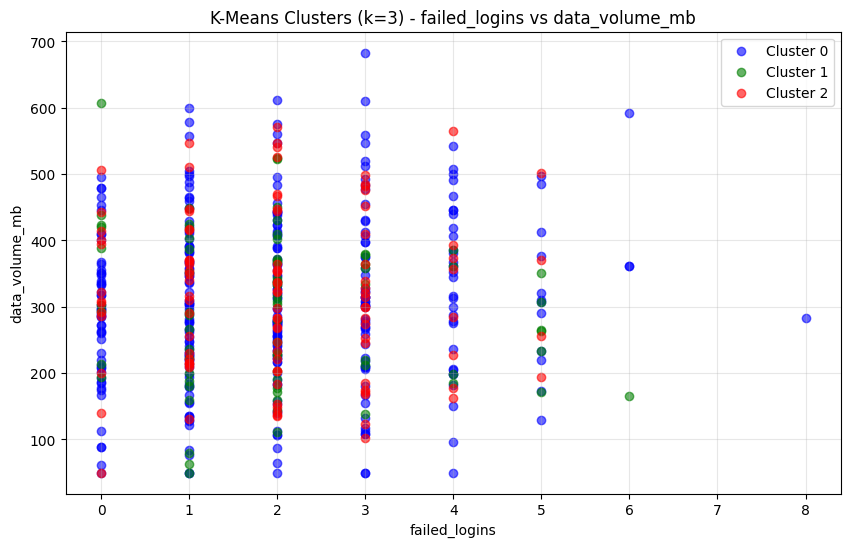


Observation:
• Clusters show some separation but also overlap
• This is expected since clustering used all 5 features


In [43]:
# Student code here

feature1 = 'failed_logins'
feature2 = 'data_volume_mb'

# Create scatter plot
plt.figure(figsize=(10, 6))
colors = ['blue', 'green', 'red']

for cluster in range(3):
    cluster_data = df_clusters[df_clusters['cluster'] == cluster]
    plt.scatter(cluster_data[feature1], cluster_data[feature2],
                c=colors[cluster], label=f'Cluster {cluster}', alpha=0.6)

plt.xlabel(feature1)
plt.ylabel(feature2)
plt.title(f'K-Means Clusters (k=3) - {feature1} vs {feature2}')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("\nObservation:")
print("• Clusters show some separation but also overlap")
print("• This is expected since clustering used all 5 features")

## Task 3 — Anomaly Detection with Isolation Forest

**Goal:**  
Detect unusual network sessions **without using labels**.

**What to do:**  
- Train an **Isolation Forest** model using the scaled input features.  
- Predict which sessions are anomalies.  
- Count how many sessions are flagged as anomalies.

**What to observe:**  
- Are anomalies rare compared to normal sessions?  
- Do anomalous sessions tend to have higher risk scores?

**Reminder:**  
Isolation Forest does not use `risk_score` for training.  
Risk score is used only to interpret the results.

Note: Isolation Forest is a tree-based anomaly detection method.
It works by isolating rare data points faster than normal ones.
You do not need to understand its internal tree structure for this lab.



In [44]:
# Student code here

iso_forest = IsolationForest(contamination=0.1, random_state=42)
anomaly_pred = iso_forest.fit_predict(X_scaled)

# Convert predictions: 1 = normal, -1 = anomaly
df_clusters['anomaly_if'] = anomaly_pred
df_clusters['is_anomaly_if'] = (anomaly_pred == -1)

# Count anomalies
n_anomalies = df_clusters['is_anomaly_if'].sum()
n_normal = len(df_clusters) - n_anomalies

print("="*50)
print("ISOLATION FOREST RESULTS")
print("="*50)
print(f"Normal sessions: {n_normal} ({n_normal/len(df_clusters)*100:.1f}%)")
print(f"Anomalies detected: {n_anomalies} ({n_anomalies/len(df_clusters)*100:.1f}%)")

# Check risk scores of anomalies
anomaly_risk = df_clusters[df_clusters['is_anomaly_if']]['risk_score'].mean()
normal_risk = df_clusters[~df_clusters['is_anomaly_if']]['risk_score'].mean()

print(f"\nAverage Risk Score:")
print(f"  Normal sessions: {normal_risk:.2f}")
print(f"  Anomalies: {anomaly_risk:.2f}")

if anomaly_risk > normal_risk:
    print("Anomalies have HIGHER risk scores on average")
else:
    print("Anomalies have LOWER risk scores on average")


ISOLATION FOREST RESULTS
Normal sessions: 450 (90.0%)
Anomalies detected: 50 (10.0%)

Average Risk Score:
  Normal sessions: 34.30
  Anomalies: 58.95
Anomalies have HIGHER risk scores on average


## Task 4 — Neural Network for Anomaly Detection

**Goal:**  
Detect anomalous network sessions by learning normal behavior using a neural network.

**What to do:**  
- Train a neural network to **reconstruct the input features**.  
- Compute the **reconstruction error** for each session.  
- Flag sessions with **high reconstruction error** as anomalies.

**What to observe:**  
- Are only a small number of sessions flagged as anomalies?  
- Do sessions with high reconstruction error tend to have higher risk scores?

**Reminder:**  
The neural network does not use `risk_score` for training.  
Risk score is used only to interpret the detected anomalies.


In [45]:
# Student code here

mlp = MLPRegressor(hidden_layer_sizes=(64, 32),
                   activation='relu',
                   max_iter=500,
                   random_state=42)

# Train to predict the input itself (autoencoder)
mlp.fit(X_scaled, X_scaled)

# Get predictions (reconstructions)
X_pred = mlp.predict(X_scaled)

# Calculate reconstruction error (MSE for each sample)
reconstruction_errors = np.mean((X_scaled - X_pred)**2, axis=1)

# Add to dataframe
df_clusters['reconstruction_error'] = reconstruction_errors

# Set threshold for anomalies (top 10% highest error)
threshold = np.percentile(reconstruction_errors, 90)
df_clusters['is_anomaly_nn'] = reconstruction_errors > threshold

# Count anomalies
n_anomalies_nn = df_clusters['is_anomaly_nn'].sum()

print("="*50)
print("NEURAL NETWORK (AUTOENCODER) RESULTS")
print("="*50)
print(f"Normal sessions: {len(df_clusters)-n_anomalies_nn} ({(len(df_clusters)-n_anomalies_nn)/len(df_clusters)*100:.1f}%)")
print(f"Anomalies detected: {n_anomalies_nn} ({n_anomalies_nn/len(df_clusters)*100:.1f}%)")

# Check risk scores of anomalies
anomaly_risk_nn = df_clusters[df_clusters['is_anomaly_nn']]['risk_score'].mean()
normal_risk_nn = df_clusters[~df_clusters['is_anomaly_nn']]['risk_score'].mean()

print(f"\nAverage Risk Score:")
print(f"  Normal sessions: {normal_risk_nn:.2f}")
print(f"  Anomalies: {anomaly_risk_nn:.2f}")

if anomaly_risk_nn > normal_risk_nn:
    print("Anomalies have HIGHER risk scores on average")
else:
    print("Anomalies have LOWER risk scores on average")

# Show top anomalies
print("\n" + "="*50)
print("TOP 5 ANOMALIES (Highest Reconstruction Error)")
print("="*50)
top_anomalies = df_clusters.nlargest(5, 'reconstruction_error')[['failed_logins', 'data_volume_mb', 'unusual_time', 'patch_age_days', 'admin_login', 'risk_score', 'reconstruction_error']]
print(top_anomalies.round(2))

NEURAL NETWORK (AUTOENCODER) RESULTS
Normal sessions: 450 (90.0%)
Anomalies detected: 50 (10.0%)

Average Risk Score:
  Normal sessions: 35.66
  Anomalies: 46.73
Anomalies have HIGHER risk scores on average

TOP 5 ANOMALIES (Highest Reconstruction Error)
     failed_logins  data_volume_mb  unusual_time  patch_age_days  admin_login  \
43               0          139.92             1              99            0   
430              1          211.85             1              24            0   
58               1          215.76             1              27            0   
88               5          501.32             1             101            0   
12               4           50.00             0             280            0   

     risk_score  reconstruction_error  
43        14.34                  0.05  
430       32.20                  0.04  
58        30.94                  0.04  
88        71.58                  0.03  
12        39.26                  0.03  


## Final Reflection — Comparing Anomaly Detection Methods

You applied two different anomaly detection approaches:

- **Isolation Forest** (Task 3)
- **Neural Network (Reconstruction Error)** (Task 4)

Answer briefly:

1. Which method detected anomalies with higher average risk scores?
* Isolation Forest detected higher risk anomalies(58.95 vs 46.73)   

2. Did both methods detect a similar number of anomalies?
* Yes, both detected exactly 50 anomalies(10% of the data)
3. Do you expect both methods to flag the same sessions? Why or why not?
* No,different methods find different types of anomalies :- isolation Forest finds rare, isolated points, Neural Network finds patterns it can't reconstruct well. They likely only overlap on some sessions, not all.
4. In a real cyber risk system, would you use one method or both? Explain.
* They find different anomalies, so using both catches more threats. Sessions flagged by both methods are especially suspicious.


## Final Checklist

- [x] All tasks completed
- [x] All cells run without errors
- [x] Notebook renamed to `Lab3_StudentID.ipynb`
- [x] Downloaded and submitted the `.ipynb`
